In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
data=pd.read_csv('amazon_orders.csv')
data

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,O024996,C07416,2023-03-15,2023,3,Q1,Wednesday,Sports Socks 6-Pack,Clothing & Apparel,59.18,...,Credit Card,Mobile,4,2023-03-19,Delivered,0,NaN,7.9,7,1
24996,O024997,C04387,2024-04-22,2024,4,Q2,Monday,Shower Curtain,Home & Kitchen,81.17,...,Cryptocurrency,Desktop,4,2024-04-26,Delivered,0,NaN,134.7,16,1
24997,O024998,C07566,2023-06-07,2023,6,Q2,Wednesday,Collagen Peptides,Health & Wellness,28.92,...,Credit Card,Desktop,5,2023-06-12,Delivered,0,4.6,4.2,16,1
24998,O024999,C04986,2024-05-06,2024,5,Q2,Monday,Energy Bars 12-Pack,Food & Grocery,19.43,...,Credit Card,Mobile,4,2024-05-10,Delivered,0,4.3,13.5,9,1


FINDING TOTAL ROWS AND COLUMNS OF DATASET

In [3]:
data.shape

(25000, 28)

TOTAL COLUMNS OF THE DATASET

In [4]:
data.describe(include='object').T

,count,unique,top,freq
order_id,25000,25000,O000001,1
customer_id,25000,7663,C03007,12
order_date,25000,2281,2020-08-25,22
quarter,25000,4,Q1,6963
day_of_week,25000,7,Monday,3658
product_name,25000,140,Portable Charger 20000mAh,497
category,25000,14,Electronics,4526
payment_method,25000,7,Credit Card,9522
device_used,25000,3,Mobile,13989
delivery_date,25000,2290,2022-02-07,22


TOTAL ORDERED PRODUCT_NAME 

TOTAL NULLS VALUES FOR EACH COLUMNS AND COLUMNS DATA_TYPES

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      25000 non-null  object 
 1   customer_id                   25000 non-null  object 
 2   order_date                    25000 non-null  object 
 3   year                          25000 non-null  int64  
 4   month                         25000 non-null  int64  
 5   quarter                       25000 non-null  object 
 6   day_of_week                   25000 non-null  object 
 7   product_name                  25000 non-null  object 
 8   category                      25000 non-null  object 
 9   unit_price_usd                25000 non-null  float64
 10  quantity                      25000 non-null  int64  
 11  subtotal_usd                  25000 non-null  float64
 12  discount_pct                  25000 non-null  int64  
 13  d

In [6]:
','.join(data['product_name'].unique())

'Tire Inflator,Stud Earrings Gold,Pen Set Premium,Smart Watch Series 5,Gaming Mouse RGB,Pull-up Bar,Tote Bag Canvas,Shower Curtain,Winter Jacket,Dashcam 4K,Running Shoes,Protein Powder Vanilla,The Lean Startup,Sunscreen SPF50,LED Desk Lamp,Wireless Earbuds Pro,Yoga Mat Non-slip,Car Phone Mount,Deep Work,Formal Dress Shirt,Omega-3 Fish Oil,Silk Scarf,Portable Scale,Ring Set 5pc,Dark Chocolate 85%,Hiking Backpack,Portable Charger 20000mAh,Shampoo Argan Oil,Electric Kettle,Cycling Gloves,Melatonin 5mg,Desk Organizer,Mechanical Keyboard,USB-C Hub,Mattress Topper,Wall Clock Modern,Flea Collar,Vitamin C Serum,Leather Belt,Smart Plug 4-Pack,Casual Sneakers,Energy Bars 12-Pack,Jump Rope Speed,Ashwagandha Extract,Slim Fit Jeans,Compression Socks,Python Crash Course,Storage Containers,Coffee Maker Drip,USB Car Charger,Hoodie Pullover,Toiletry Bag,Sunglasses UV400,Hyaluronic Acid Moisturizer,Knife Set 8pc,Bluetooth Speaker,Clean Code,Zinc Lozenges,Sports Socks 6-Pack,Stuffed Animal Bear,Phone Cas

TOTAL ORDERED PRODUCT CATEGORY

In [7]:
','.join(data['category'].unique())

'Automotive,Jewelry & Accessories,Office Supplies,Electronics,Sports & Outdoors,Home & Kitchen,Clothing & Apparel,Food & Grocery,Books,Beauty & Personal Care,Health & Wellness,Travel & Luggage,Pet Supplies,Toys & Games'

AVAILABLE PAYMENT_METHODS IN AMAZON

In [8]:
','.join(data['payment_method'].unique())

'Credit Card,PayPal,Debit Card,Cryptocurrency,UPI / Digital Wallet,Buy Now Pay Later,Bank Transfer'

FINDING THE NULL VALUES FOR EACH COLUMNS

In [9]:
data.isnull().sum()

order_id                            0
customer_id                         0
order_date                          0
year                                0
month                               0
quarter                             0
day_of_week                         0
product_name                        0
category                            0
unit_price_usd                      0
quantity                            0
subtotal_usd                        0
discount_pct                        0
discount_amount_usd                 0
shipping_fee_usd                    0
tax_pct                             0
tax_amount_usd                      0
total_amount_usd                    0
payment_method                      0
device_used                         0
delivery_days                       0
delivery_date                       0
order_status                        0
returned                            0
customer_rating                 15749
session_duration_minutes            0
pages_viewed

FINDING THE DUPLICATED VALUES FOR EACH COLUMNS

In [10]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Length: 25000, dtype: bool

TO FINDING THE MOST ORDER OF THE MONTH

CREATE THE NEW COLUMNS

In [11]:
data['Unit_price_INR']=data['unit_price_usd']*90

In [12]:
data['Subtotal_INR']=data['subtotal_usd']*90

In [13]:
data['Discount_amount_INR']=data['discount_amount_usd']*90

In [14]:
data['Shipping_fee_INR']=data['shipping_fee_usd']*90

In [15]:
data['Tax_amount_INR']=data['tax_amount_usd']*90

In [16]:
data['Total_amount_INR']=data['total_amount_usd']*90

DROP THE EXISTING COLUMNS 

In [17]:
data.drop('total_amount_usd',axis=1,inplace=True)

In [18]:
data.drop(['subtotal_usd','discount_amount_usd','unit_price_usd','shipping_fee_usd'],axis=1,inplace=True)

In [19]:
data

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,quantity,...,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer,Unit_price_INR,Subtotal_INR,Discount_amount_INR,Shipping_fee_INR,Tax_amount_INR,Total_amount_INR
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,1,...,NaN,14.4,1,1,5661.9,5661.9,0.0,0.0,1018.8,6680.7
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,1,...,NaN,9.0,4,0,1659.6,1659.6,0.0,359.1,165.6,2184.3
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,1,...,4.0,3.2,17,0,9881.1,9881.1,1976.4,0.0,632.7,8537.4
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,1,...,NaN,32.2,3,1,7848.9,7848.9,3924.0,0.0,314.1,4239.0
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,2,...,2.8,54.7,2,1,8487.0,16974.0,0.0,899.1,848.7,18721.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,O024996,C07416,2023-03-15,2023,3,Q1,Wednesday,Sports Socks 6-Pack,Clothing & Apparel,1,...,NaN,7.9,7,1,5326.2,5326.2,799.2,0.0,0.0,4527.0
24996,O024997,C04387,2024-04-22,2024,4,Q2,Monday,Shower Curtain,Home & Kitchen,5,...,NaN,134.7,16,1,7305.3,36526.5,0.0,899.1,2922.3,40347.9
24997,O024998,C07566,2023-06-07,2023,6,Q2,Wednesday,Collagen Peptides,Health & Wellness,5,...,4.6,4.2,16,1,2602.8,13014.0,0.0,629.1,2342.7,15985.8
24998,O024999,C04986,2024-05-06,2024,5,Q2,Monday,Energy Bars 12-Pack,Food & Grocery,2,...,4.3,13.5,9,1,1748.7,3497.4,0.0,0.0,279.9,3777.3


In [20]:
mean_values=data['customer_rating'].mean()
data['customer_rating'].fillna(mean_values,inplace=True)

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\3320522585.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['customer_rating'].fillna(mean_values,inplace=True)


In [21]:
data.duplicated().sum()

np.int64(0)

TOTAL DELIVERED PRODUCTS -20497

In [22]:
data.loc[data['order_status'].str.contains('Delivered')].value_counts().sum()

np.int64(20497)

TOTAL RETURNED PRODUCTS -2020

In [23]:
data.loc[data['order_status'].str.contains('Returned')].value_counts().sum()

np.int64(2020)

TOTAL CANCELLED PRODUCTS -1456

In [24]:
data.loc[data['order_status'].str.contains('Cancelled')].value_counts().sum()

np.int64(1456)

TOTAL PROCESSING ORDERS -1027

In [25]:
data.loc[data['order_status'].str.contains('Processing')].value_counts().sum()

np.int64(1027)

COUNT_PLOT FOR SHOWS MOST ORDERED AMAZON PRODUCT NAME - [MOST ORDERED PRODUCT_NAME : PORTABLE CHARGER 200000MAH] [LEAST ORDERED PRODUCT NAME:TRAVEL PILLOW MEMORY FOAM]

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\3556570870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(y='product_name',data=data,order=data['product_name'].value_counts().index,palette='viridis')


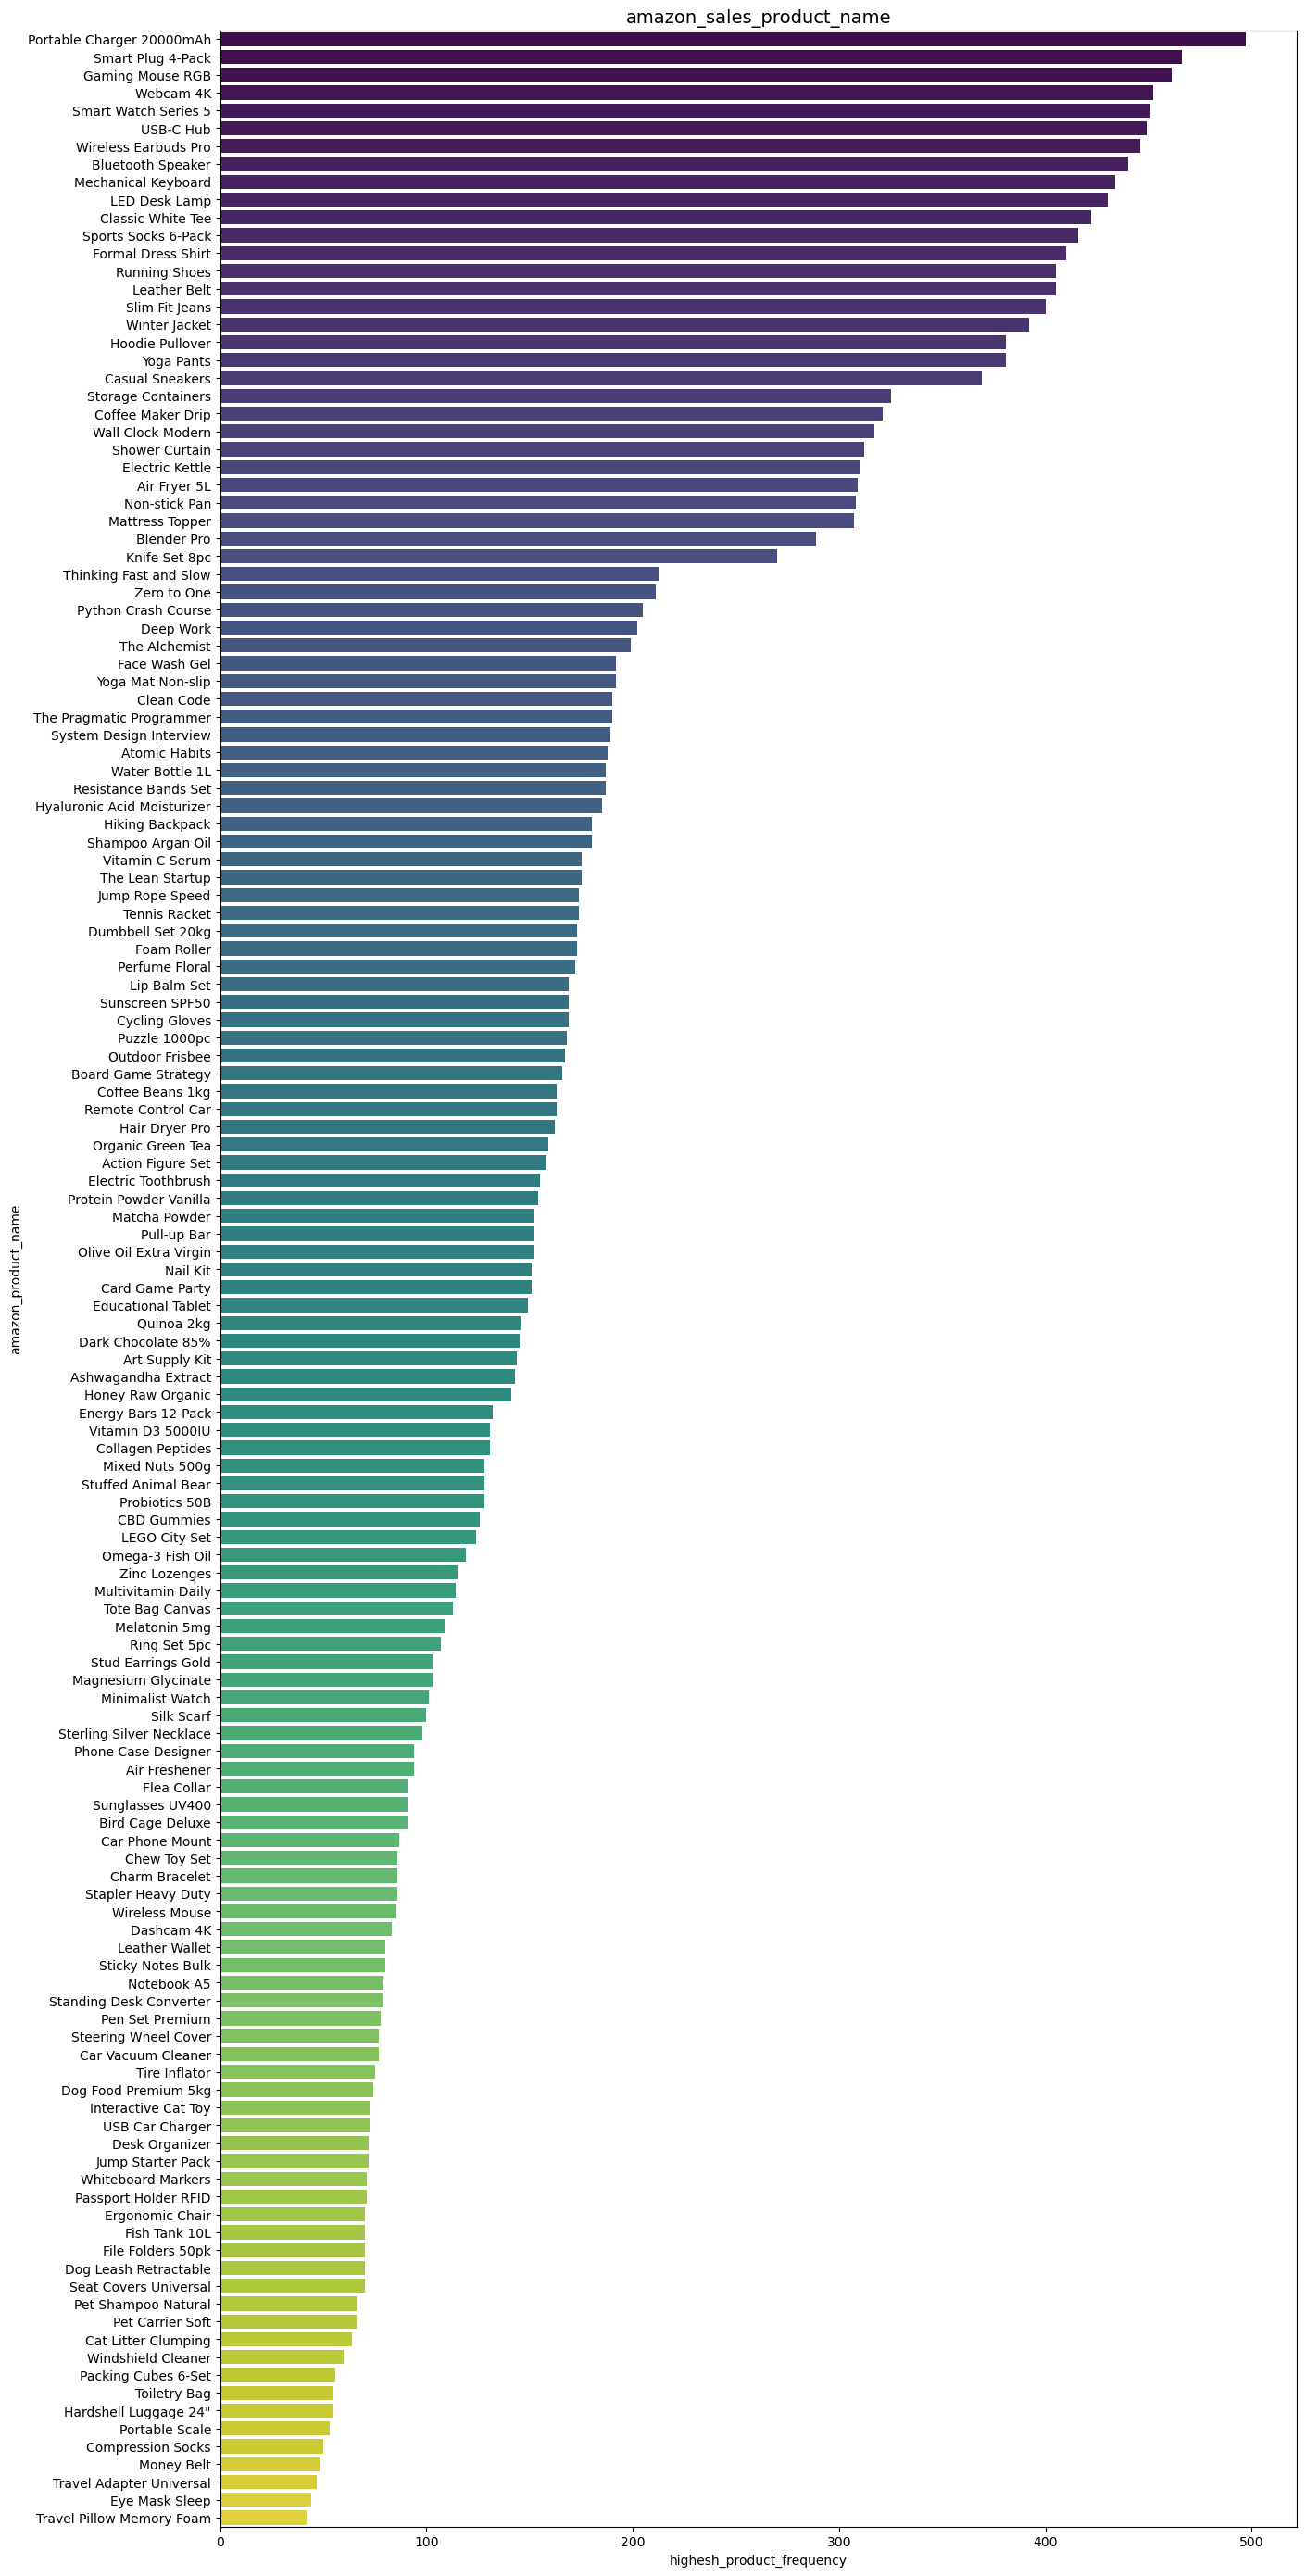

In [26]:
plt.figure(figsize=(15,35))
sbn.countplot(y='product_name',data=data,order=data['product_name'].value_counts().index,palette='viridis')
plt.title('amazon_sales_product_name',fontsize=14)
plt.xlabel('highesh_product_frequency')
plt.ylabel('amazon_product_name')
plt.show()

HISTOGRAM PLOT FOR SHOWS PRODUCT QUANTITY AND SUB_TOTAL
[MOST ORDERED PRODUCT QUANTITY = 1]
[HIGHEST SUBTOTAL_AMOUNT OF PRODUCT QUANTITY=4-5]

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\1774137942.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sbn.histplot(x=data['quantity'].dropna(),y=data['Subtotal_INR'],data=data,kde=True,bins=20,palette='viridis')


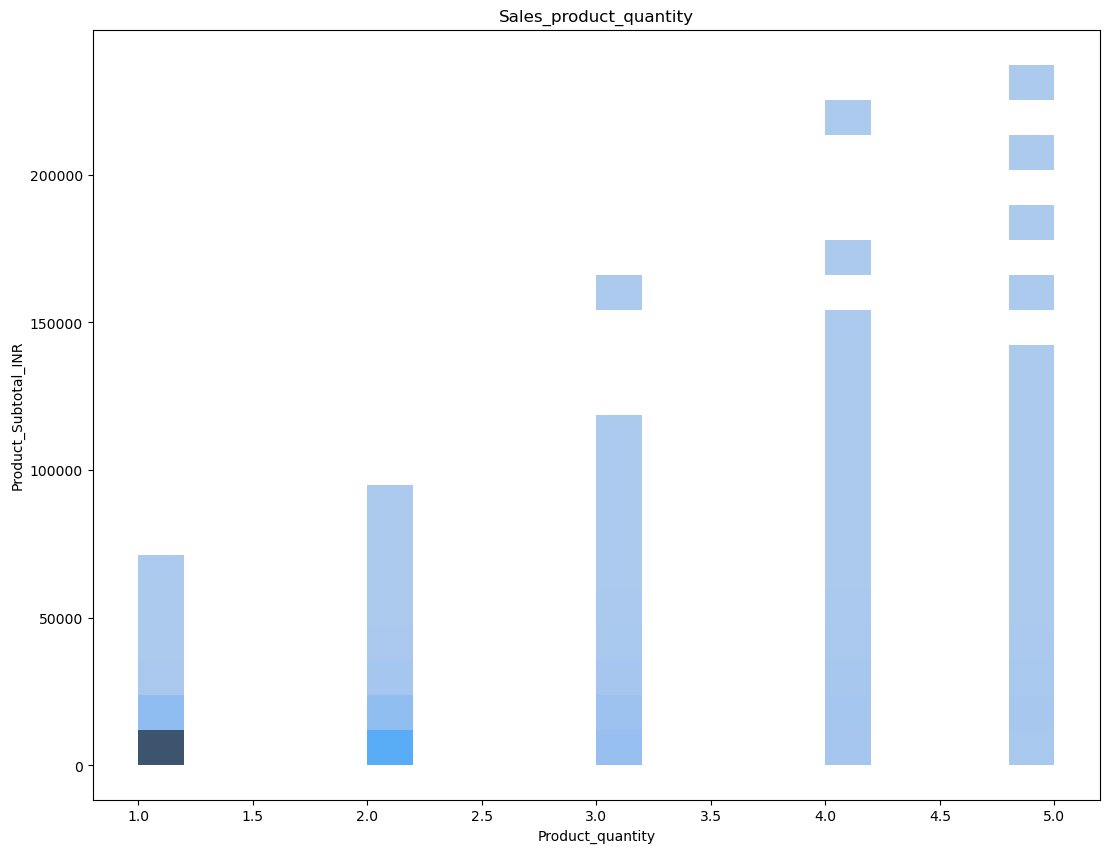

In [27]:
plt.figure(figsize=(13,10))
sbn.histplot(x=data['quantity'].dropna(),y=data['Subtotal_INR'],data=data,kde=True,bins=20,palette='viridis')
plt.title('Sales_product_quantity')
plt.xlabel('Product_quantity')
plt.ylabel('Product_Subtotal_INR')
plt.show()

COUNT_PLOT FOR MOST ORDERED PRODUCT_CATEGORY - [MOST ORDERED PRODUCT CATEGORY : ELECTRONICS] [LEAST ORDERED PRODUCT CATEGORY: TRAVEL & LUGGAGE]

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\674966808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(y='category',data=data,order=data['category'].value_counts().index,palette='viridis')


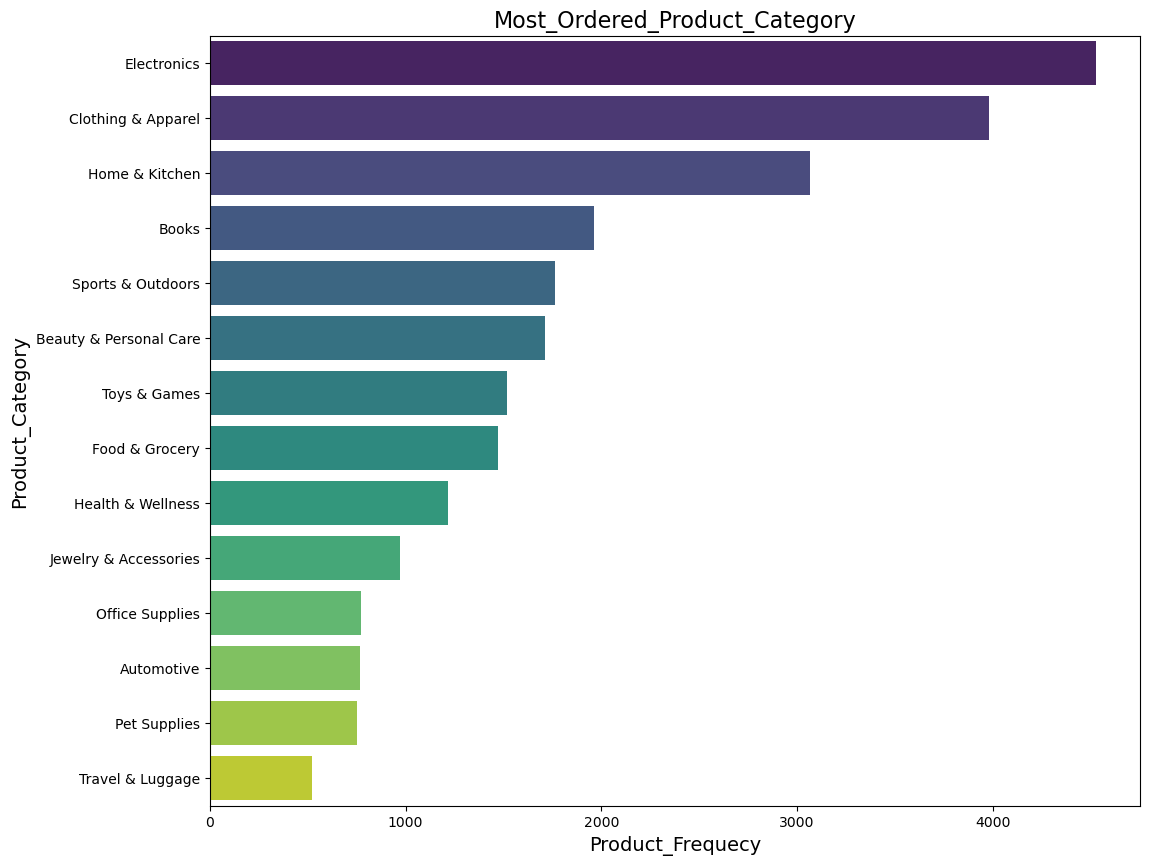

In [28]:
plt.figure(figsize=(12,10))
sbn.countplot(y='category',data=data,order=data['category'].value_counts().index,palette='viridis')
plt.title('Most_Ordered_Product_Category',fontsize=16)
plt.xlabel('Product_Frequecy',fontsize=14)
plt.ylabel('Product_Category',fontsize=14)
plt.show()

HISTGRAM_PLOT FOR MOST SESSION DURATION MINUTES OF PRODUCT CATEGORY - [MOST PRODUCT_SESSION_DURATION_MINUTES:ELECTRONICS,CLOTHES & APPAREL, FOOD & GROCERY]

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\1858903285.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sbn.histplot(x=data['category'].dropna(),y=data['session_duration_minutes'],data=data,kde=True,bins=20,palette='viridis')


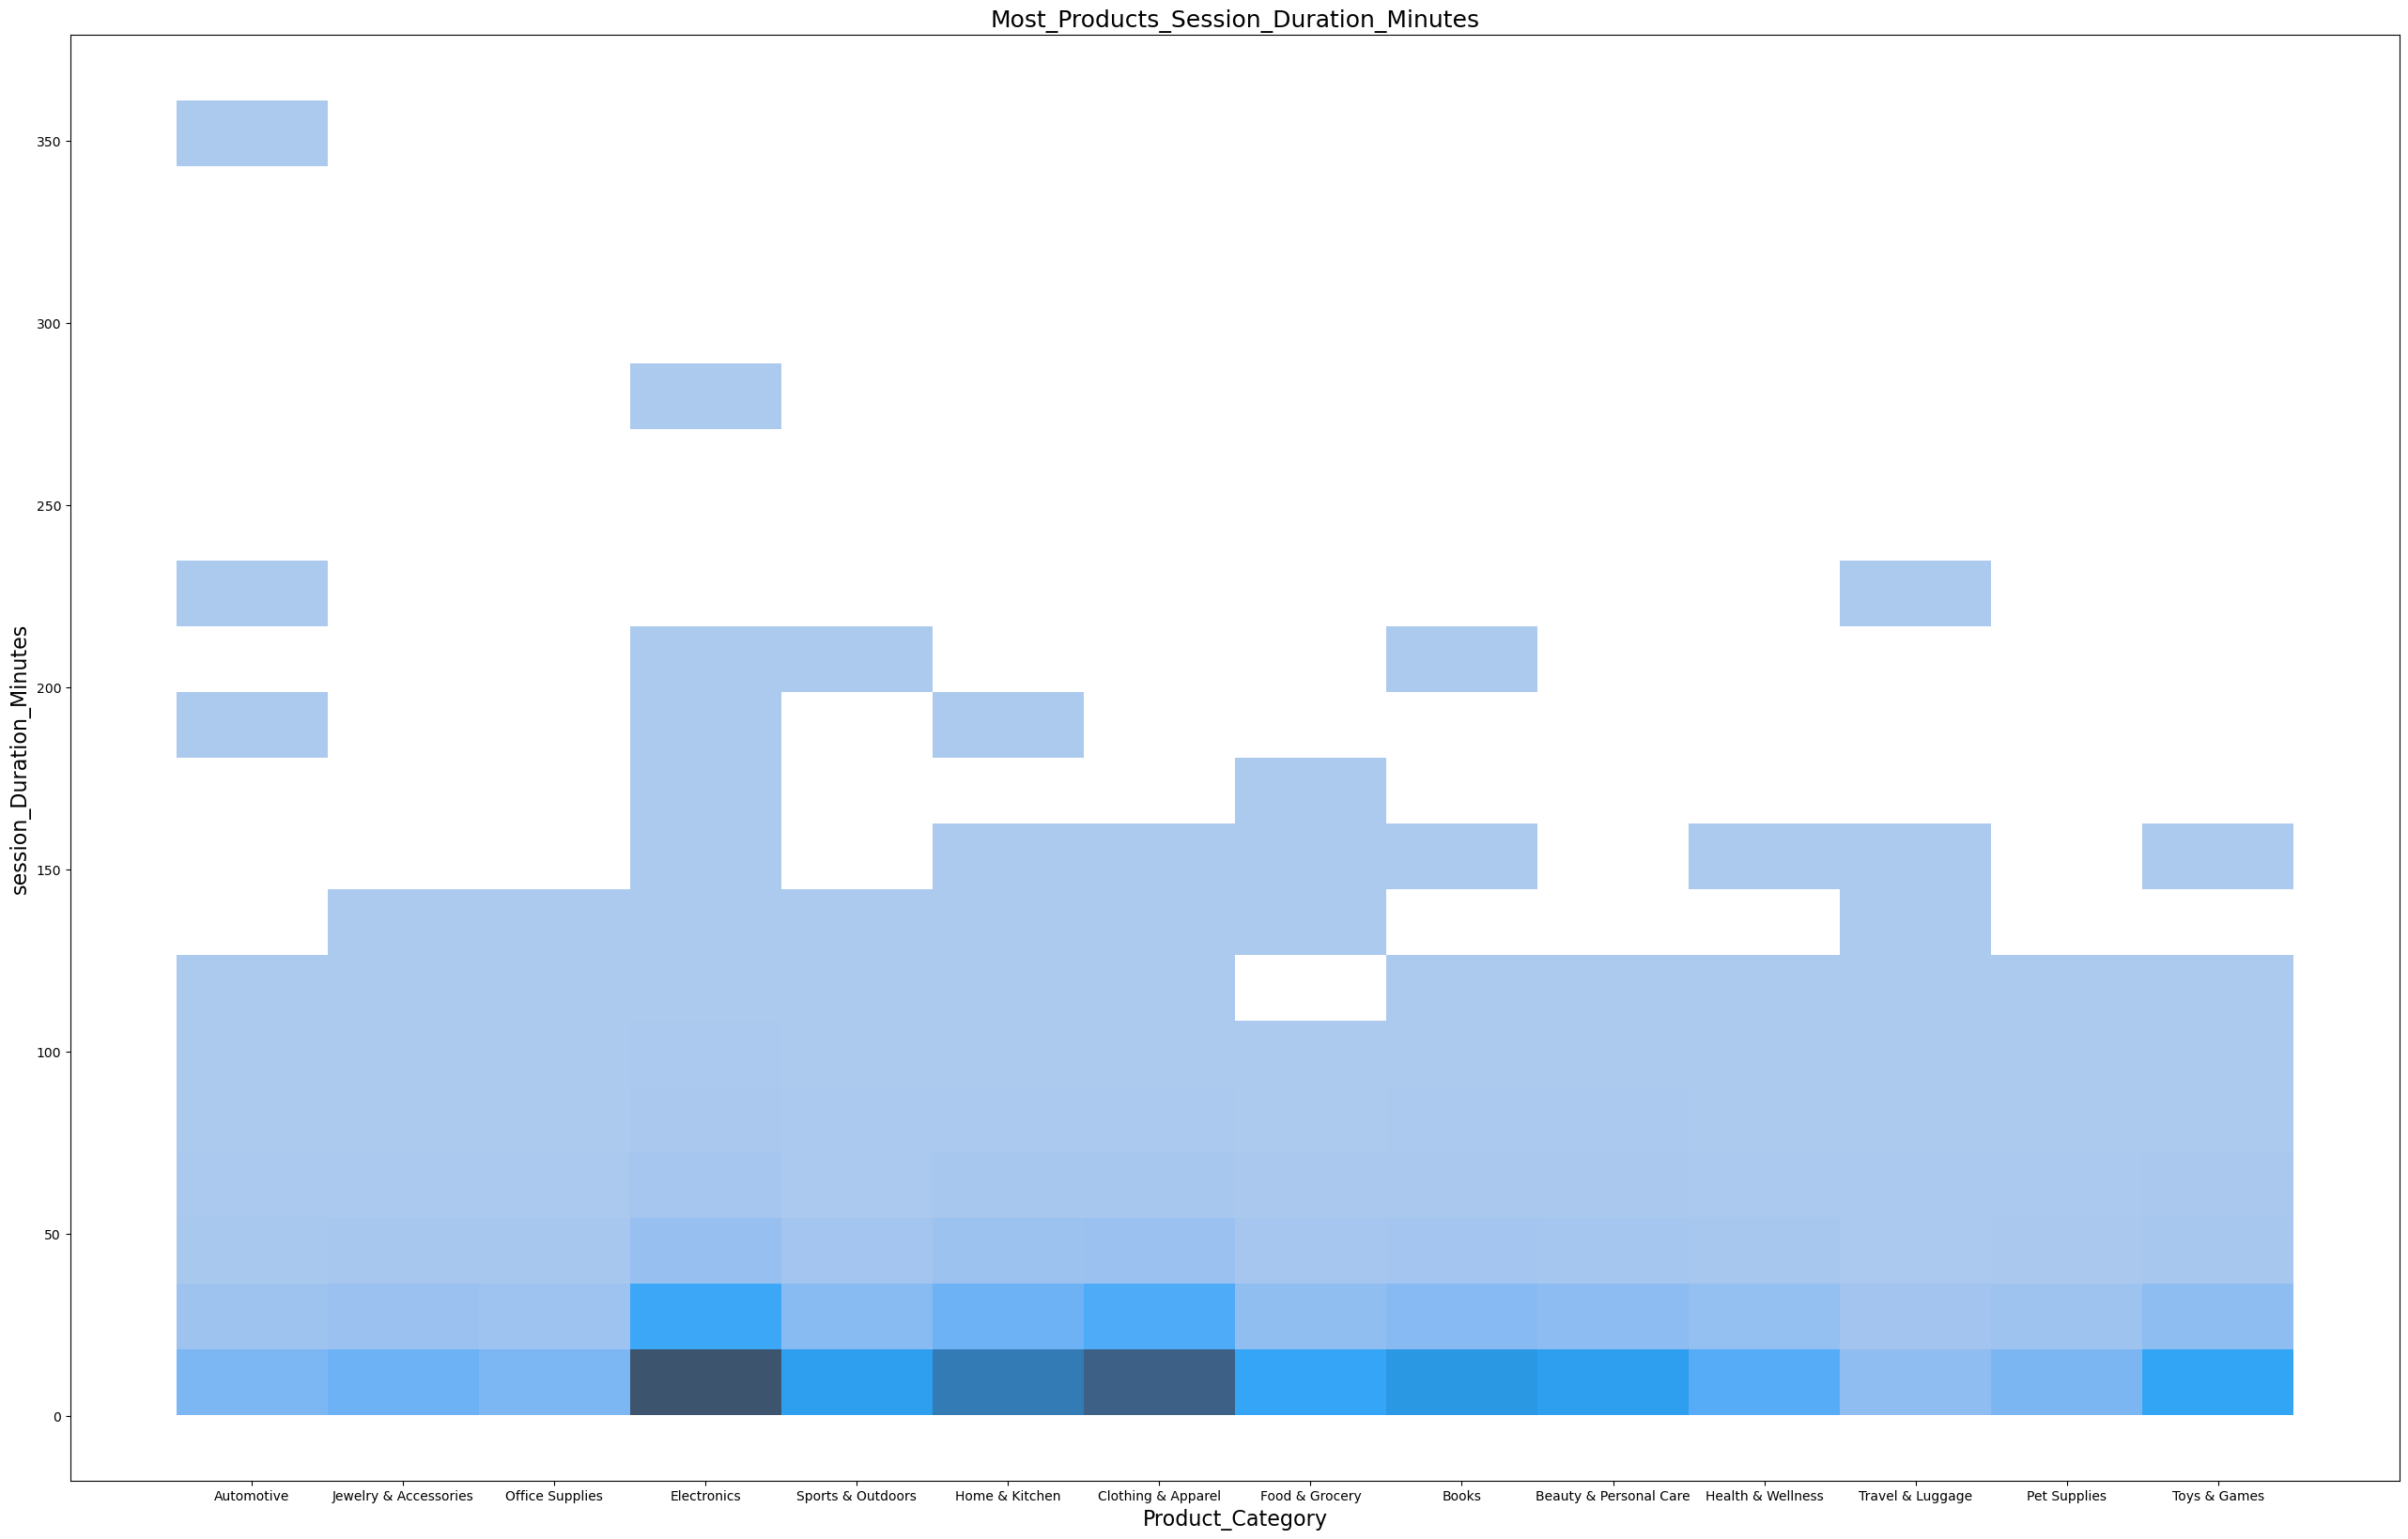

In [29]:
plt.figure(figsize=(32,20))
sbn.histplot(x=data['category'].dropna(),y=data['session_duration_minutes'],data=data,kde=True,bins=20,palette='viridis')
plt.title('Most_Products_Session_Duration_Minutes',fontsize=18)
plt.xlabel('Product_Category',fontsize=16)
plt.ylabel('session_Duration_Minutes',fontsize=16)
plt.show()

LINE_PLOT FOR MOST AMAZON PRODUCT ORDERED YEAR

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\2586362829.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sbn.lineplot(x=data['category'].dropna(),data=data,y=data['delivery_days'],palette='viridis')


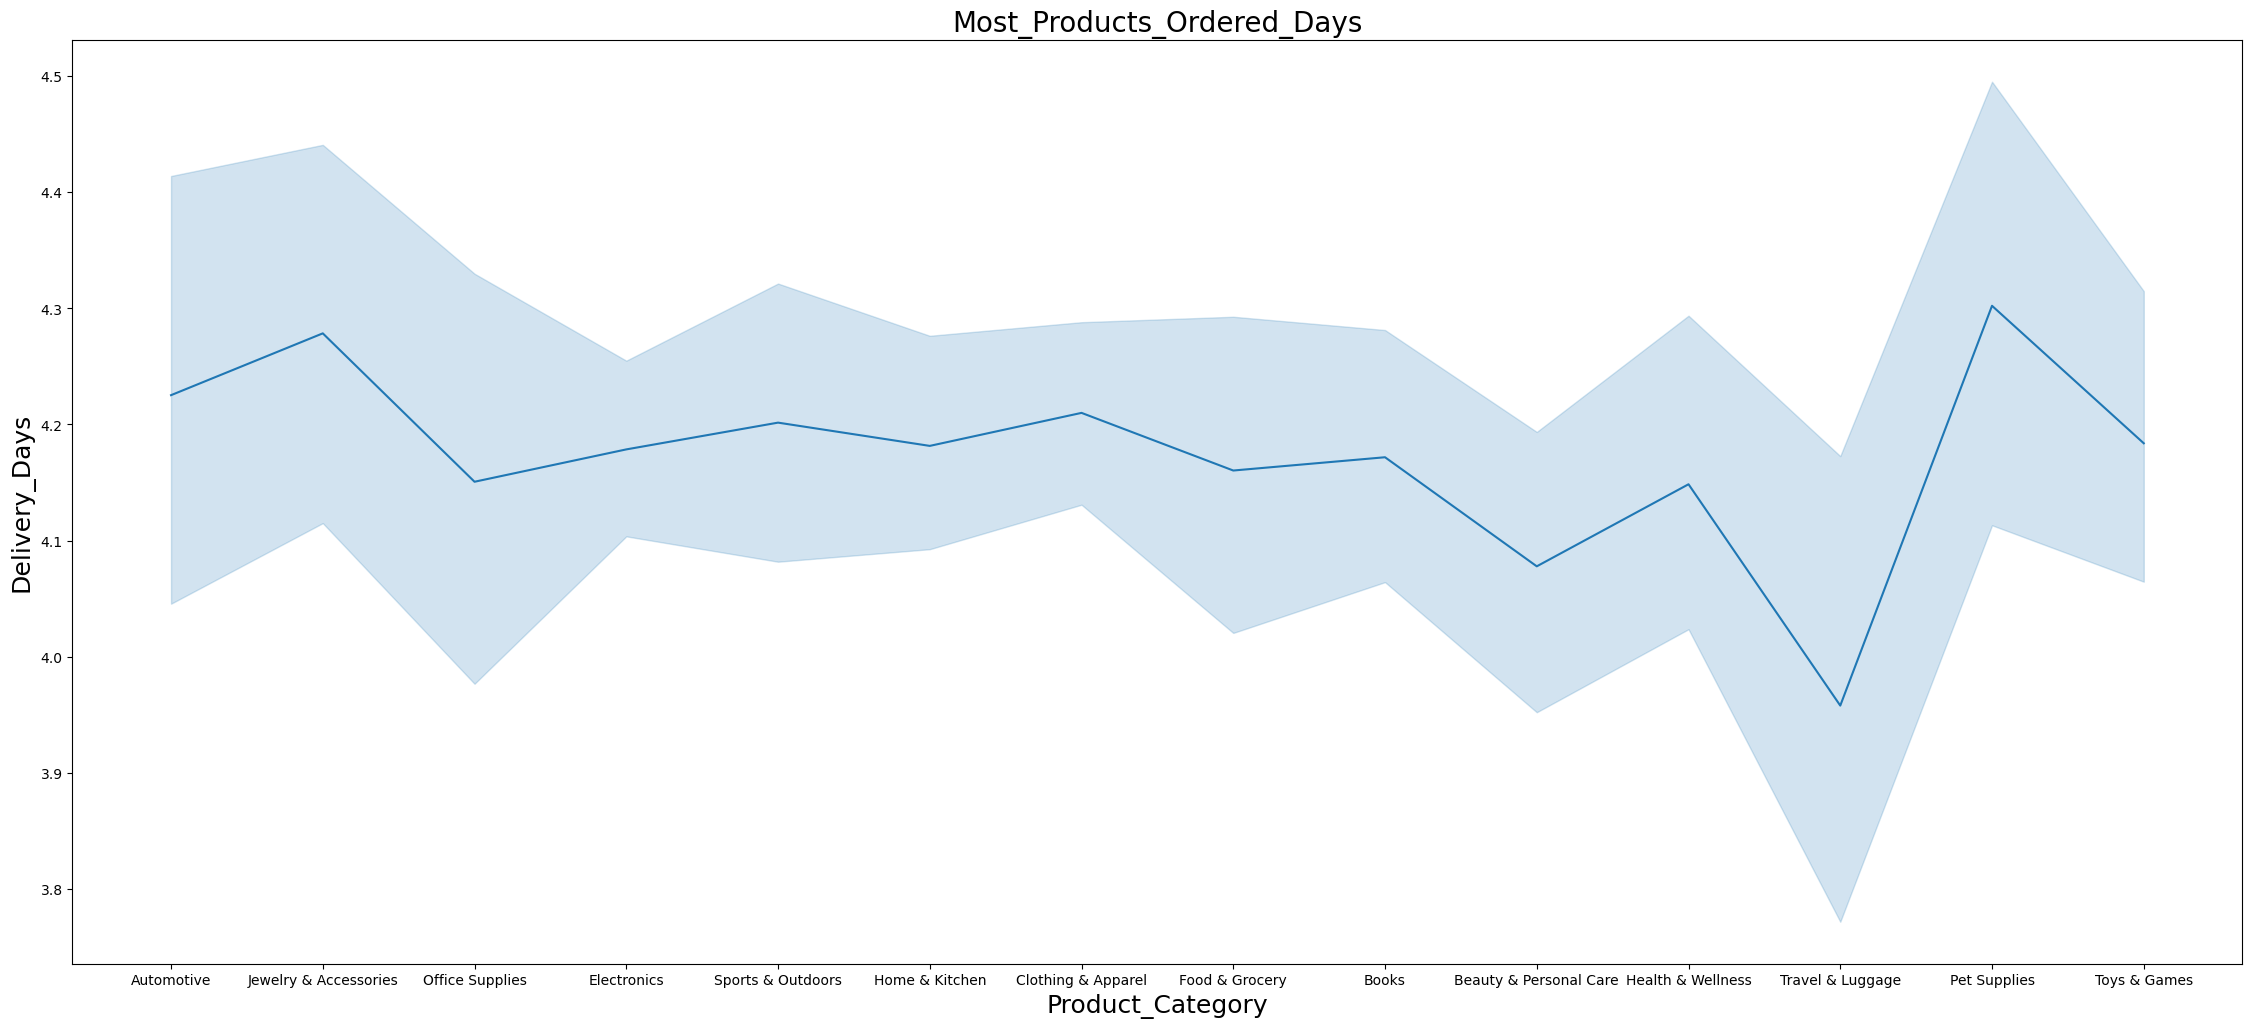

In [30]:
plt.figure(figsize=(28,12))
sbn.lineplot(x=data['category'].dropna(),data=data,y=data['delivery_days'],palette='viridis')
plt.title('Most_Products_Ordered_Days',fontsize=20)
plt.xlabel('Product_Category',fontsize=18)
plt.ylabel('Delivery_Days',fontsize=18)
plt.show()

HIST_PLOT FOR SHOW MOST_ORDERED PRODUCT CATEGORY - [MOST ORDERED PRODUCT CATEGORY - ELECTRONICS ] [LEAST ORDERED PRODUCT CATEGORY - TRAVELS AND LUGGAGE]

C:\Users\adhit\AppData\Local\Temp\ipykernel_10612\575496870.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sbn.histplot(x=data['category'].dropna(),y=data['delivery_days'],data=data,kde=True,bins=20,palette='viridis')


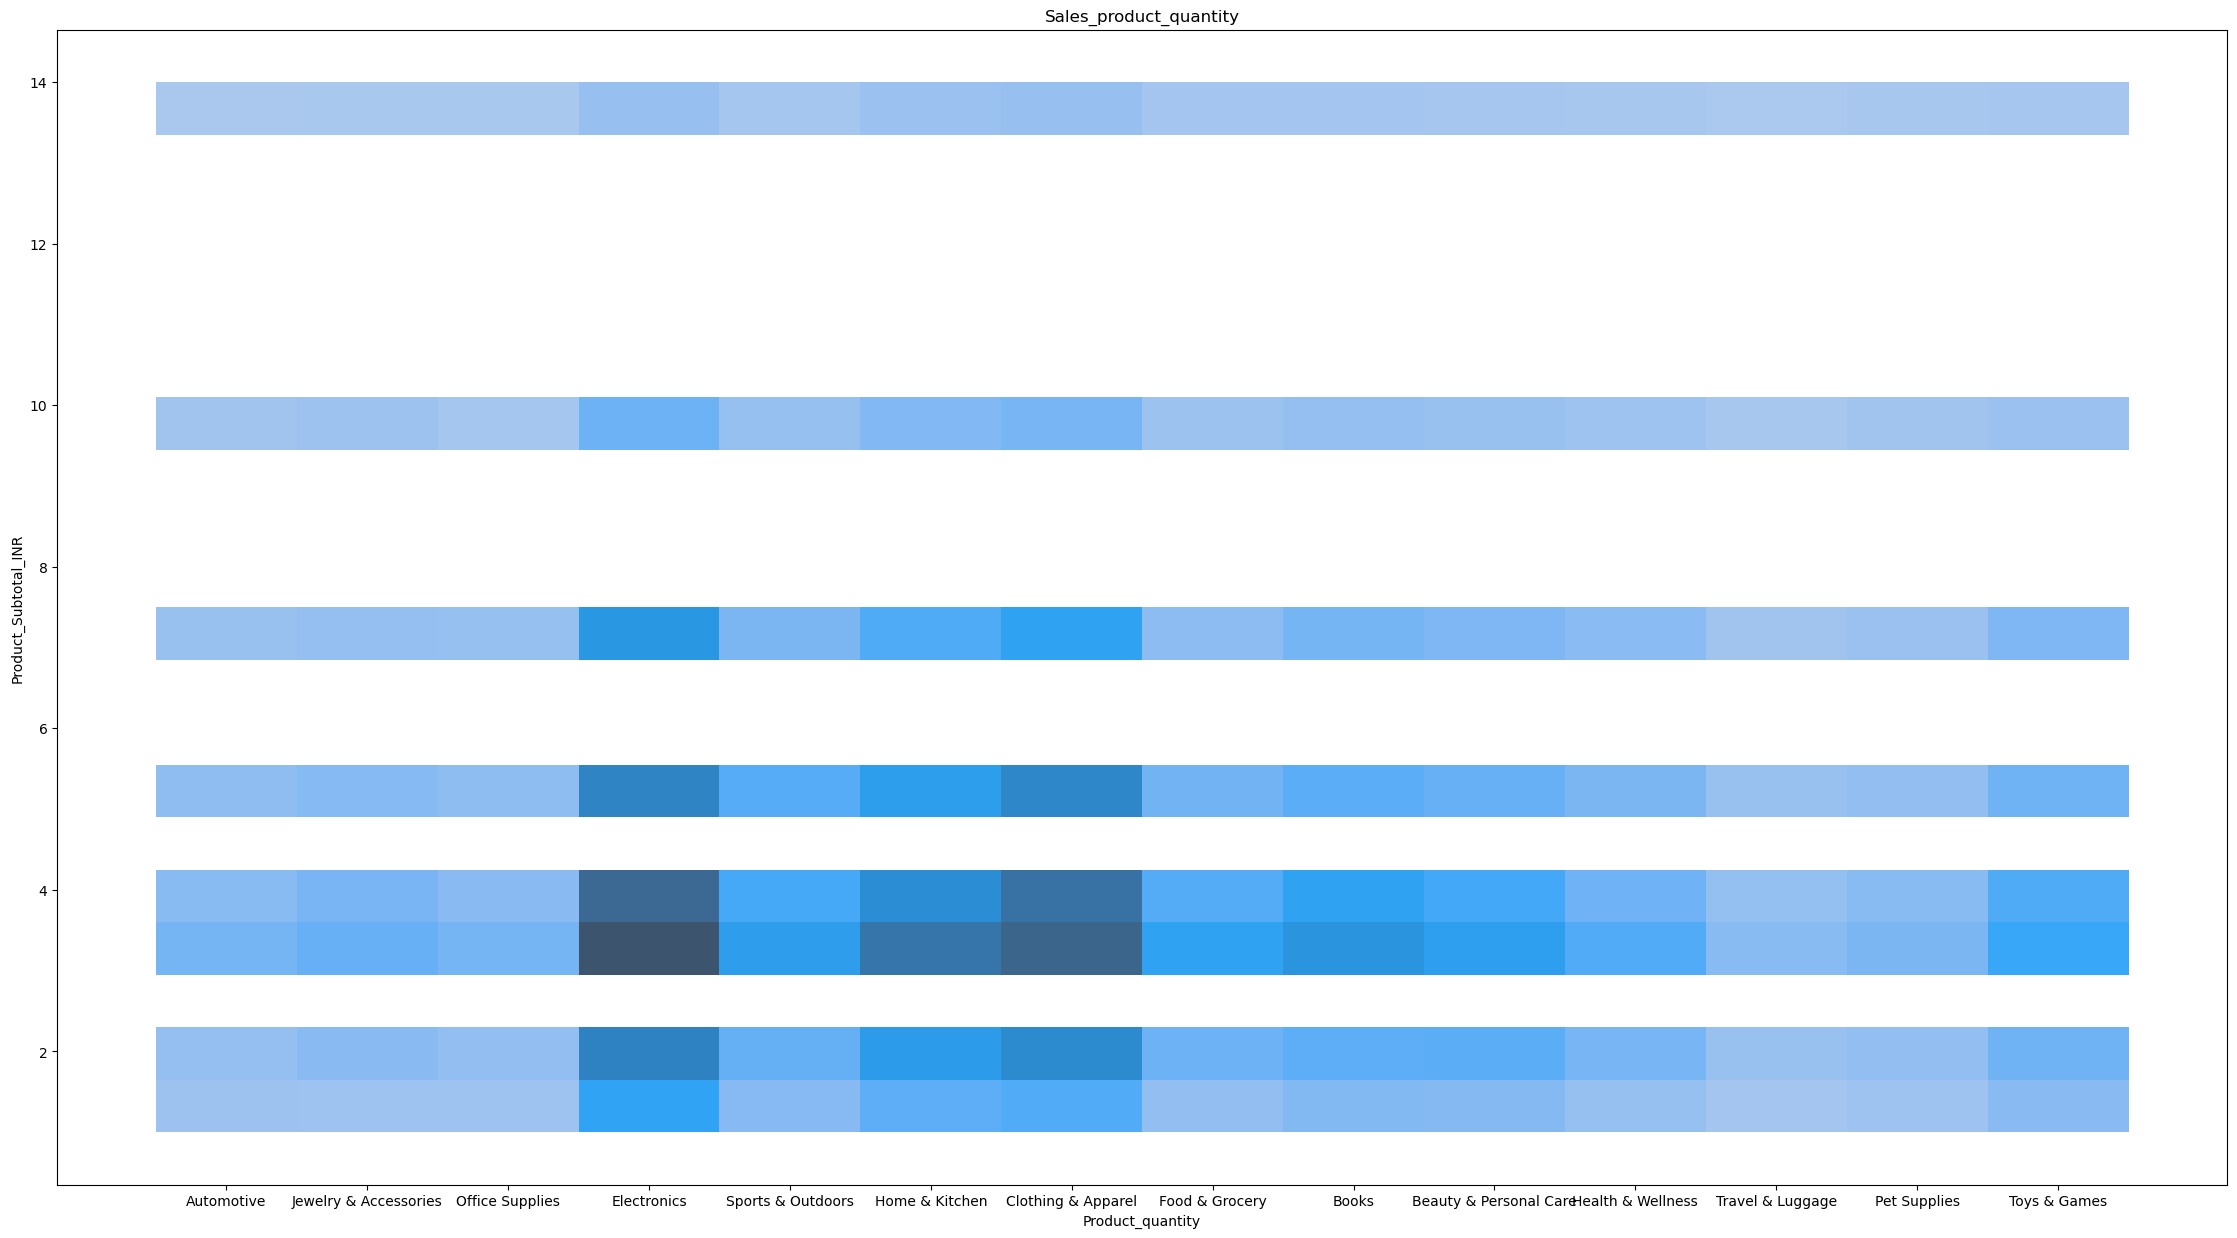

In [31]:
plt.figure(figsize=(28,15))
sbn.histplot(x=data['category'].dropna(),y=data['delivery_days'],data=data,kde=True,bins=20,palette='viridis')
plt.title('Sales_product_quantity')
plt.xlabel('Product_quantity')
plt.ylabel('Product_Subtotal_INR')
plt.show()